# Example 4 - Laser and Raman Photon Path Tracing 

Monte Carlo simulations track individual photon packets as they propagate
through a turbid medium — scattering, converting, and eventually either
escaping or being absorbed. This notebook lets you visualise those trajectories
directly.

---

## What this simulation models

The NMC Raman kernel launches photons into a tissue-like scattering volume of width
$w$ (mm). Each photon undergoes:

- **Elastic scattering** — direction changes governed by the Henyey–Greenstein
  phase function with anisotropy factor $g$
- **Raman scattering** — spontaneous inelastic event, probability `raman_prob`
  per step; converts a Laser photon (type 1) into a Raman photon (type 2)
- **Stimulated Raman scattering (SRS)** — probability `stim_raman_prob`;
  produces an SRS photon (type 3)
- **Absorption** — governed by $\mu_a$; terminates the photon packet

The simulation volume is a cube $[-w,\,w]\times[-w,\,w]\times[0,\,w]$ mm,
where $z = 0$ is the illuminated (top) surface. Photons are focused at depth
$z_\text{focus}$ through a lens of numerical aperture NA.

---

## Photon types

| Type | Label | Physical meaning |
|------|-------|-----------------|
| 1 | **Laser** | Incident excitation photon — has not undergone inelastic scattering |
| 2 | **Raman** | Spontaneous Raman-converted photon |
| 3 | **SRS** | Stimulated Raman-scattered photon |
| 0 | *(termination)* | Final row of each trajectory; z-coordinate encodes the fate |

A trajectory **ends** when `type == 0`. The terminal z-coordinate tells us the
photon's fate:

$$
\text{exit state} = \begin{cases}
\text{top}      & z_\text{end} \approx 0      \quad\text{(back-scattered)}\\
\text{bottom}   & z_\text{end} \approx w      \quad\text{(transmitted)}\\
\text{absorbed} & \text{otherwise}
\end{cases}
$$

The **photon type** assigned to a trajectory is the last non-zero type seen
before termination — i.e. what the photon *was* when it exited or was absorbed.

---

## Workflow

| Cell | Action |
|------|--------|
| **2** | Set simulation parameters and path to the NMC executable |
| **3** | Write config files; check whether outputs already exist |
| **4** | Run the simulation (skipped automatically if output is found) |
| **5** | Load trajectory data into two tables: `df_raw` and `df_summary` |
| **6** | Draw a random sample of complete trajectories for plotting |
| **7** | Static plot — depth vs time ($z$–$t$ traces) |
| **8** | Static plot — depth vs radial distance ($z$–$r$ traces) |
| **9** | Interactive 3-D animation — propagation of a chosen photon type |

---

## Output files used

| File pattern | Contents |
|---|---|
| `photons_data_mus-*_NA-*_zf-*.csv` | Full photon trajectories: position, time, weight, type at every sampled step |

---

## Key parameters

| Parameter | Symbol | Unit | Effect |
|-----------|--------|------|--------|
| `mu_s` | $\mu_s$ | mm⁻¹ | Scattering coefficient — higher → shorter mean free path |
| `mu_a` | $\mu_a$ | mm⁻¹ | Absorption coefficient |
| `g` | $g$ | — | Anisotropy: 0 = isotropic, 1 = fully forward |
| `zfocus` | $z_f$ | mm | Focal depth of the beam |
| `numerial_aperture` | NA | — | Collection / focusing aperture |
| `raman_prob` | — | — | Per-step probability of spontaneous Raman conversion |
| `width` | $w$ | mm | Half-width of the simulation volume |

> **Tip — re-running:** if you change any parameter in Cell 2, delete the
> existing `photons_data_*.csv` from the build folder so Cell 3 triggers a
> fresh simulation run.

In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ── make nmc_utils importable as `nmc` ───────────────────────────────────────
NOTEBOOK_DIR = Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
import nmc_utils as nmc

nmc.set_paper_style()
print("nmc_utils loaded")

nmc_utils loaded


In [14]:
# ── paths ─────────────────────────────────────────────────────────────────────
# Default: relative path from NMC-samples/ to the build folder.
# Override with an absolute Path if your build lives elsewhere:
#   EXE_DIR = Path("/Users/you/wherever/NMC/Build/Products/Debug")
EXE_DIR  = (NOTEBOOK_DIR / "../NMC/Build/Products/Debug").resolve()
EXE_NAME = "nmc"
EXE_PATH = EXE_DIR / EXE_NAME

# ── simulation parameters ─────────────────────────────────────────────────────
PARAMS = dict(
    fname                  = "example",
    width                  = 0.5,    # mm  — simulation box full-width
    Nx                     = 100,
    Ny                     = 100,
    Nz                     = 100,
    mu_a                   = 0.1,    # mm-1  absorption coefficient
    mu_s                   = 10.0,   # mm-1  scattering coefficient
    g                      = 0.6,    #       anisotropy factor
    index_of_refraction    = 1.6,
    zfocus                 = 1.0,    # mm  focal depth
    numerial_aperture      = 1.0,    # -   NA
    laser_beam_radius      = 0.05,   # mm
    laser_beam_pulse_width = 5.0,    # ps
    laser_beam_pulse_delay = 15.0,   # ps
    raman_prob             = 0.05,
    stim_raman_prob        = 0.1,
)

# ── plotting controls ─────────────────────────────────────────────────────────
N_TRAJ_PLOT   = 30          # trajectories per type for static plots
TYPES_PLOT    = [1, 2]   # photon types to include
SAVE_FIGS     = False
FIGS_DIR      = NOTEBOOK_DIR / "figs"
FIGS_DIR.mkdir(exist_ok=True)

print(f"EXE  : {EXE_PATH}")
print(f"FIGS : {FIGS_DIR}")

EXE  : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug/nmc
FIGS : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC-samples/figs


In [3]:
# human-readable config → notebook folder
# machine-readable .mci → build folder (next to the exe)
mci_path, cfg_path = nmc.init_config_file(
    cfg_dir=NOTEBOOK_DIR,
    mci_dir=EXE_DIR,
    **PARAMS,
)
print(f"CFG written : {cfg_path}")
print(f"MCI written : {mci_path}")

# ── derive expected output filename from params ───────────────────────────────
mus = PARAMS["mu_s"]
NA  = PARAMS["numerial_aperture"]
zf  = PARAMS["zfocus"]
expected_output = f"photons_data_mus-{mus:.2f}_NA-{NA:.2f}_zf-{zf:.2f}.csv"

existing = nmc.find_outputs(expected_output, workdir=EXE_DIR)
if existing:
    print(f"\nOutput already exists : {existing[0].name}")
    print("Skipping simulation — delete the file to re-run.")
    RUN_NEEDED = False
else:
    print(f"\nNo output found for : {expected_output}")
    print("Simulation will run in Cell 4.")
    RUN_NEEDED = True

CFG written : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC-samples/config file example.txt
MCI written : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug/example_H.mci

No output found for : photons_data_mus-10.00_NA-1.00_zf-1.00.csv
Simulation will run in Cell 4.


In [4]:
if RUN_NEEDED:
    nmc.run(
        exe_path=EXE_PATH,
        mci_name=PARAMS["fname"],
        workdir=EXE_DIR,
    )
else:
    print("Skipped (output already exists).")

[nmc] Command : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug/nmc example
[nmc] cwd     : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug
[nmc] ── simulation output ──────────────────
[nmc] ─────────────────────────────────────
[nmc] stderr:
2026-03-05 15:34:40.961 nmc[94077:4178365] Reading file example_H.mci
2026-03-05 15:34:40.961 nmc[94077:4178365] Hello, let's do Raman!
2026-03-05 15:34:40.962 nmc[94077:4178365] 
GEOMETRY:
2026-03-05 15:34:40.962 nmc[94077:4178365] width = 0.50 mm
2026-03-05 15:34:40.962 nmc[94077:4178365] Nx = 100, Ny = 100, Nz = 100
2026-03-05 15:34:40.962 nmc[94077:4178365] 
RUN:
2026-03-05 15:34:40.962 nmc[94077:4178365] step size = 0.0010 [mm]
2026-03-05 15:34:40.962 nmc[94077:4178365] detection state = 0
2026-03-05 15:34:40.962 nmc[94077:4178365] 
MEDIUM:
2026-03-05 15:34:40.962 nmc[94077:4178365] muav[1] = 0.1000 [mm^-1]
2026-03-05 15:34:40.962 nmc[94077:4178365] musv[1] = 10.0000 [mm^-1]
2026-03-05 15:34:40.962 n

In [5]:
photons_csv = EXE_DIR / expected_output

df_raw, df_summary = nmc.load_photons(
    photons_csv,
    z_bottom=PARAMS["width"],
    types_of_interest=tuple(TYPES_PLOT),
)

# attach readable label columns
df_raw["type_label"]     = df_raw["type"].map(nmc.TYPE_LABELS)
df_summary["type_label"] = df_summary["prev_type"].map(nmc.TYPE_LABELS)

print(f"\ndf_raw    : {df_raw.shape}")
print(f"df_summary: {df_summary.shape}")

[load_photons] Total rows       : 10,879,252
[load_photons] Unique markers   : 100,000
[load_photons] Summarised       : 100,000  (after type filter: [1, 2])
[load_photons] No type-0 row    : 147  (term_mode='no_term')
[load_photons] Degenerate skip  : 0  (only type-0 rows — no prev_type available)

[load_photons] Exit state counts (post-filter):
bottom      42551
top         40838
absorbed    16611

[load_photons] prev_type counts (post-filter):
1    94587
2     5413

df_raw    : (10879252, 8)
df_summary: (100000, 8)


In [6]:
rng = np.random.default_rng(seed=42)

sampled_markers = []
for ptype in TYPES_PLOT:
    pool = df_summary.loc[df_summary["prev_type"] == ptype, "marker"].values
    n    = min(N_TRAJ_PLOT, len(pool))
    sampled_markers.extend(rng.choice(pool, size=n, replace=False).tolist())

df_sample = df_raw[df_raw["marker"].isin(sampled_markers)].copy()

# propagation rows only — exclude type-0 termination points from line plots
df_prop = df_sample[df_sample["type"] != 0].copy()
df_prop["r"] = np.sqrt(df_prop["x"]**2 + df_prop["y"]**2)

print(f"Sampled {len(sampled_markers)} trajectories -> {len(df_prop)} propagation rows")

Sampled 60 trajectories → 4373 propagation rows


/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_93702/3991722869.py:29: UserWarning:

The figure layout has changed to tight



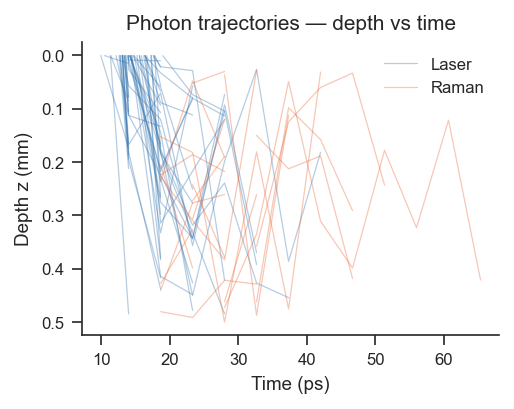

In [15]:
fig, ax = plt.subplots(figsize=(3.5, 2.8))

for ptype in TYPES_PLOT:
    color  = nmc.TYPE_COLORS[ptype]
    label  = nmc.TYPE_LABELS[ptype]
    subset = df_prop[df_prop["type"] == ptype]
    first  = True
    for _, traj in subset.groupby("marker"):
        ax.plot(
            traj["t"], traj["z"],
            color=color, alpha=0.35, linewidth=0.6,
            label=label if first else "",
        )
        first = False

handles, labels_leg = ax.get_legend_handles_labels()
seen = {}
ax.legend(
    [h for h, l in zip(handles, labels_leg) if not (l in seen or seen.update({l: True}))],
    [l for l in labels_leg if l],
    frameon=False,
)

ax.set_xlabel("Time (ps)")
ax.set_ylabel("Depth z (mm)")
ax.set_title("Photon trajectories — depth vs time")
ax.invert_yaxis()   # z = 0 at top (entry surface)
sns.despine(ax=ax)
fig.tight_layout()

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex1_zt_traces.pdf", bbox_inches="tight")
plt.show()

/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_93702/937854717.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


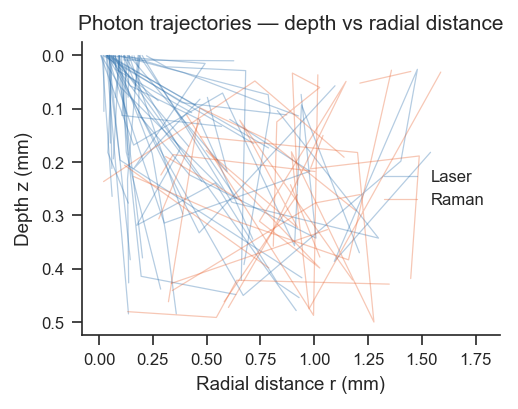

In [9]:
fig, ax = plt.subplots(figsize=(3.5, 2.8))

for ptype in TYPES_PLOT:
    color  = nmc.TYPE_COLORS[ptype]
    label  = nmc.TYPE_LABELS[ptype]
    subset = df_prop[df_prop["type"] == ptype]
    first  = True
    for _, traj in subset.groupby("marker"):
        ax.plot(
            traj["r"], traj["z"],
            color=color, alpha=0.35, linewidth=0.6,
            label=label if first else "",
        )
        first = False

handles, labels_leg = ax.get_legend_handles_labels()
seen = {}
ax.legend(
    [h for h, l in zip(handles, labels_leg) if not (l in seen or seen.update({l: True}))],
    [l for l in labels_leg if l],
    frameon=False,
)

ax.set_xlabel("Radial distance r (mm)")
ax.set_ylabel("Depth z (mm)")
ax.set_title("Photon trajectories — depth vs radial distance")
ax.invert_yaxis()
sns.despine(ax=ax)
fig.tight_layout()

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex1_zr_traces.pdf", bbox_inches="tight")
plt.show()

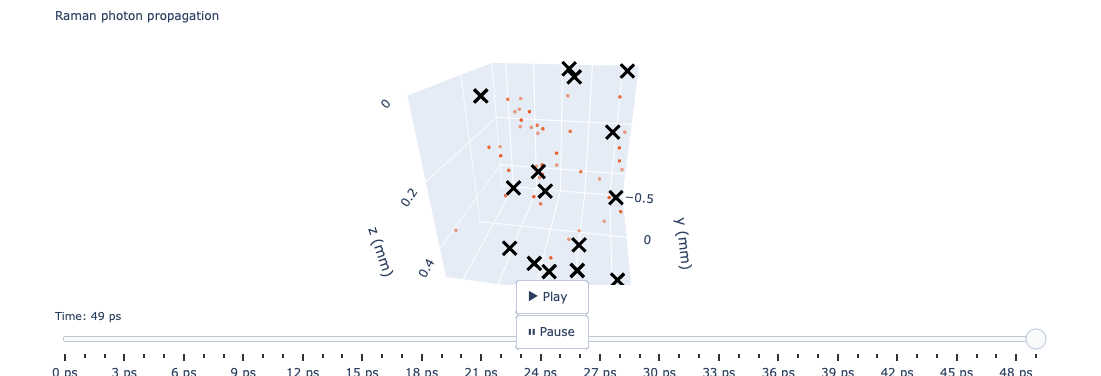

In [10]:
# ── user controls for animation ───────────────────────────────────────────────
ANIM_TYPE   = 2      # photon type to animate: 1 = Laser, 2 = Raman, 3 = SRS
N_TRAJ_ANIM = 50     # max number of trajectories to show (keep <200 for performance)
N_FRAMES    = 50     # number of time frames

# ── 1. select trajectories of the requested type ─────────────────────────────
width = PARAMS["width"]
color = nmc.TYPE_COLORS[ANIM_TYPE]
label = nmc.TYPE_LABELS[ANIM_TYPE]

anim_markers = df_summary.loc[
    df_summary["prev_type"] == ANIM_TYPE, "marker"
].values

rng_anim = np.random.default_rng(seed=0)
anim_markers = rng_anim.choice(
    anim_markers,
    size=min(N_TRAJ_ANIM, len(anim_markers)),
    replace=False,
)

# ── 2. slice each trajectory to the active segment of ANIM_TYPE ──────────────
# Keep only rows where type == ANIM_TYPE (the photon IS that type)
# plus the first type-0 termination row so we see where it ends.
segments = []
for marker in anim_markers:
    traj = df_raw[df_raw["marker"] == marker].copy()
    traj = traj.sort_values("t").reset_index(drop=True)

    # find first index where type becomes ANIM_TYPE
    type_rows = traj[traj["type"] == ANIM_TYPE]
    if type_rows.empty:
        continue
    t_birth = type_rows["t"].iloc[0]

    # keep from birth onwards (includes trailing type-0 termination if present)
    seg = traj[traj["t"] >= t_birth].copy()
    seg["marker"] = marker
    segments.append(seg)

if not segments:
    raise RuntimeError(f"No trajectories found for type {ANIM_TYPE}.")

df_anim = pd.concat(segments, ignore_index=True)

# ── 3. build time axis — always starts at 0 ───────────────────────────────────
t_max   = df_anim["t"].max()
t_edges = np.linspace(0.0, t_max, N_FRAMES + 1)
t_mids  = 0.5 * (t_edges[:-1] + t_edges[1:])

# ── 4. cumulative trail: for frame fi show all points with t <= t_edges[fi+1] ─
plotly_frames = []
for fi in range(N_FRAMES):
    t_cut  = t_edges[fi + 1]
    fdata  = df_anim[df_anim["t"] <= t_cut]

    # propagation points (type == ANIM_TYPE)
    prop  = fdata[fdata["type"] == ANIM_TYPE]
    # termination points (type == 0) — mark differently
    term  = fdata[fdata["type"] == 0]

    frame_traces = [
        go.Scatter3d(
            x=prop["x"], y=prop["y"], z=prop["z"],
            mode="markers",
            marker=dict(size=2, color=color, opacity=0.6),
            name=label,
            showlegend=(fi == 0),
        ),
        go.Scatter3d(
            x=term["x"], y=term["y"], z=term["z"],
            mode="markers",
            marker=dict(size=4, color="black", symbol="x", opacity=0.8),
            name="Terminated",
            showlegend=(fi == 0),
        ),
    ]
    plotly_frames.append(go.Frame(data=frame_traces, name=str(fi)))

# ── 5. volume wireframe ───────────────────────────────────────────────────────
w = width
# 12 edges of the box, separated by None
xs = [-w, w,None, w, w,None, w,-w,None,-w,-w,None,  # bottom face
      -w,-w,None, w, w,None, w, w,None,-w,-w,None,  # verticals
      -w, w,None, w,-w,None,-w,-w,None, w, w,None]  # top face — corrected
ys = [-w,-w,None,-w, w,None, w, w,None, w,-w,None,
      -w,-w,None,-w,-w,None, w, w,None, w, w,None,
      -w,-w,None,-w,-w,None, w, w,None, w, w,None]
zs = [ w, w,None, w, w,None, w, w,None, w, w,None,
       w, 0,None, w, 0,None, w, 0,None, w, 0,None,
       0, 0,None, 0, 0,None, 0, 0,None, 0, 0,None]

box_trace = go.Scatter3d(
    x=xs, y=ys, z=zs,
    mode="lines",
    line=dict(color="lightgrey", width=1),
    name="Volume",
    showlegend=False,
    hoverinfo="skip",
)

# ── 6. layout ─────────────────────────────────────────────────────────────────
layout = go.Layout(
    title=dict(
        text=f"{label} photon propagation",
        font=dict(size=12),
    ),
    scene=dict(
        xaxis=dict(title="x (mm)", range=[-w, w]),
        yaxis=dict(title="y (mm)", range=[-w, w]),
        zaxis=dict(title="z (mm)", range=[w, 0]),   # 0 at top
        aspectmode="cube",
        bgcolor="white",
    ),
    legend=dict(itemsizing="constant"),
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            y=0.02, x=0.5, xanchor="center",
            buttons=[
                dict(
                    label="▶ Play",
                    method="animate",
                    args=[None, dict(
                        frame=dict(duration=100, redraw=True),
                        fromcurrent=True,
                        transition=dict(duration=0),
                    )],
                ),
                dict(
                    label="⏸ Pause",
                    method="animate",
                    args=[[None], dict(
                        frame=dict(duration=0, redraw=False),
                        mode="immediate",
                    )],
                ),
            ],
        )
    ],
    sliders=[
        dict(
            steps=[
                dict(
                    method="animate",
                    args=[[str(fi)], dict(
                        mode="immediate",
                        frame=dict(duration=0, redraw=True),
                        transition=dict(duration=0),
                    )],
                    label=f"{t_mids[fi]:.0f} ps",
                )
                for fi in range(N_FRAMES)
            ],
            transition=dict(duration=0),
            x=0.05, len=0.90,
            currentvalue=dict(prefix="Time: ", font=dict(size=11)),
        )
    ],
    margin=dict(l=0, r=0, b=80, t=40),
    paper_bgcolor="white",
)

fig_anim = go.Figure(
    data=[box_trace, *plotly_frames[0].data],
    layout=layout,
    frames=plotly_frames,
)
fig_anim.show()